# COMPUTATIONAL ASTROPHYSICS EXERCISES

In [239]:
import numpy as np
from matplotlib import pyplot as plt

# 1

## Ex. 1.1

Write a program to compute machine epsilon empirically by finding the smallest $\varepsilon$ such that $1+\varepsilon>1$ in floating-point. Compare with the theoretical value.

In [2]:
e = 1
while (1+e)>1:
    e = e/10
e10 = e
print(e10)

1.0000000000000001e-16


In [3]:
e = 1
while (1+e)>1:
    e = e/2
e2 = e
print(e2)

1.1102230246251565e-16


## Ex. 1.2

Implement both the naive and stable quadratic formula. Test on $a=1$, $b=10^8$, $c=1$. Compute the relative error in each root compared to the exact values.

In [4]:
def n_quad_formula(a,b,c):
    x1 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
    x2 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    x = np.array([x1,x2])
    return x

def s_quad_formula(a,b,c):
    x1 = (-b-np.sign(b)*np.sqrt(b**2-4*a*c))/(2*a)
    x2 = c/(a*x1)
    x = np.array([x1,x2])
    return x

In [5]:
a = 1
b = 1e8
c = 1

naive = n_quad_formula(a,b,c)
stable = s_quad_formula(a,b,c)

print(naive)
print(stable)

[-1.0000000e+08 -7.4505806e-09]
[-1.e+08 -1.e-08]


In [6]:
exact = np.array([-9.99999999999999899999999999999989999999999999997999999999999999499999999999999860000*1e7,-1.000000000000000100000000000000020000000000000005000000000000001400000000000000420000*1e-8])
n_rerr = (naive-exact)/exact
s_rerr = (stable-exact)/exact

print(n_rerr,s_rerr)

[ 1.49011612e-16 -2.54941940e-01] [ 1.49011612e-16 -0.00000000e+00]


## Ex. 1.3

For $x=1+10^{-k}$ and $y=1$, compute $x-y$ for $k=1,2, \ldots, 20$. Plot the relative error versus $k$. Explain the behavior.

In [7]:
def f(k):
    return 1+10**(-k)

In [8]:
x = []
corr = []
for k in range(1,21):
    x.append(f(k))
    corr.append(10**(-k))
x = np.array(x)
corr = np.array(corr)

[ 8.32667268e-17  8.67361738e-18 -1.10154941e-16 -1.10182046e-17
  6.55112222e-17 -8.22665927e-17  5.83867222e-17 -6.07747099e-17
  8.27403709e-17  8.27403710e-18  8.27403711e-19  8.89005823e-17
 -7.99277837e-17 -7.99277837e-18  1.10223025e-16 -1.00000000e-16
 -1.00000000e-17 -1.00000000e-18 -1.00000000e-19 -1.00000000e-20]


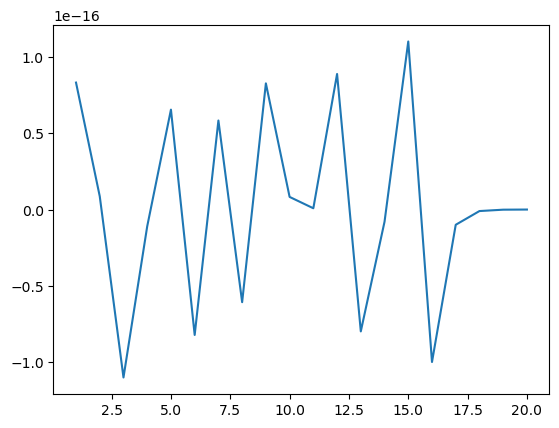

In [9]:
print((x-1-corr))
plt.plot(range(1,21),(x-1-corr))

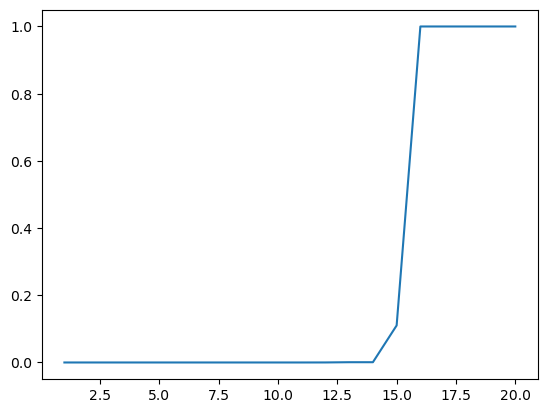

In [10]:
plt.plot(range(1,21),abs(x-1-corr)/corr)

# 2

## Ex. 2.1

Implement from scratch (do not use library quadrature)
- Rectangle rule (left endpoint, right endpoint, midpoint)
- Trapezoidal rule
- Simpson's rule (composite)

Integrate the following test functions on $[0,1]$ for $N=10,20,40,80,160,320$ subintervals:

$$
\begin{array}{ll}
f_1(x)=x^2 & (\text { exact: } 1 / 3) \\
f_2(x)=e^x & (\text { exact: } e-1) \\
f_3(x)=\sin (\pi x) & (\text { exact: } 2 / \pi) \\
f_4(x)=\frac{1}{1+x^2} & (\text { exact: } \pi / 4)
\end{array}
$$

For each rule and function:
- Compute the absolute error vs. $N$.
- Plot $\log ($ error $)$ vs. $\log (N)$ on a $\log$-log plot.
- Fit a power law: error $\propto N^{-p}$. What is $p$ for each method?
- Compare to the theoretical convergence orders (rectangle $O(h)$, trapezoidal $O\left(h^2\right)$, Simpson $O\left(h^4\right)$ ).
- Bonus: Explain why Simpson's rule achieves $O\left(h^4\right)$ even though it is based on quadratic interpolation (hint: symmetry and cancellation of the cubic error term).

In [11]:
def left_rectangle(func,xmin,xmax,N):
    integral = 0
    left = xmin
    step = (-xmin+xmax)/N
    for i in range(N):
        integral = integral + func(left) * step
        left = xmin + i * step
    return integral
def right_rectangle(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    right = xmin+step
    for i in range(N):
        integral += func(right)*step
        right += step
    return integral
def central_rectangle(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    centre = xmin + step/2
    for i in range(N):
        integral += func(centre)*step
        centre += step
    return integral

In [12]:
def trap(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    left = xmin
    right = xmin+step
    step = (-xmin+xmax)/N
    for i in range(N):
        integral = integral + (func(left)+func(right))*step/2
        left = left + step
        right = right + step
    return integral

def simpson(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    ai = xmin
    bi = xmin+step
    mi = (ai+bi)/2
    for i in range(N):
        integral = integral + (func(ai)+func(bi)+ 4*func(mi)) * step/6
        ai = ai + step
        bi = bi + step
        mi = mi + step
    return integral

def simpson_reverse(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    ai = xmax-step
    bi = xmax
    mi = (ai+bi)/2
    for i in range(N):
        integral = integral + (func(ai)+func(bi)+ 4*func(mi)) * step/6
        ai = ai - step
        bi = bi - step
        mi = mi - step
    return integral

In [13]:
'''
def left_rectangle(func,xmin,xmax,step):
    integral = 0
    left = xmin
    for i in range(int((-xmin+xmax)/step)):
        integral = integral + func(left) * step
        left = xmin + i * step
    return integral
def right_rectangle(func,xmin,xmax,step):
    integral = 0
    right = xmin+step
    for i in range(int((xmax-xmin)/step)):
        integral += func(right)*step
        right += step
    return integral
def central_rectangle(func,xmin,xmax,step):
    integral = 0
    centre = xmin + step/2
    for i in range(int((xmax-xmin)/step)):
        integral += func(centre)*step
        centre += step
    return integral
'''

'\ndef left_rectangle(func,xmin,xmax,step):\n    integral = 0\n    left = xmin\n    for i in range(int((-xmin+xmax)/step)):\n        integral = integral + func(left) * step\n        left = xmin + i * step\n    return integral\ndef right_rectangle(func,xmin,xmax,step):\n    integral = 0\n    right = xmin+step\n    for i in range(int((xmax-xmin)/step)):\n        integral += func(right)*step\n        right += step\n    return integral\ndef central_rectangle(func,xmin,xmax,step):\n    integral = 0\n    centre = xmin + step/2\n    for i in range(int((xmax-xmin)/step)):\n        integral += func(centre)*step\n        centre += step\n    return integral\n'

In [14]:
# for a pl

In [15]:
integral = left_rectangle((lambda x : x**2), 0, 1, 512) 
print(integral)

integral = right_rectangle((lambda x : x**2), 0, 1, 512) 
print(integral)

integral = central_rectangle((lambda x : x**2), 0, 1, 512) 
print(integral)

0.3304119035601616
0.33431053161621094
0.33333301544189453


In [16]:
# for an exponential

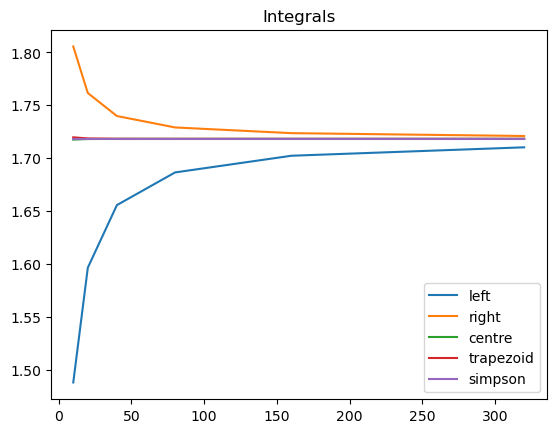

In [17]:
integral_l=[]
integral_r=[]
integral_c=[]
integral_t=[]
integral_s=[]
N = [10, 20, 40, 80, 160, 320]
for i in [10, 20, 40, 80, 160, 320]:
    integral = left_rectangle((lambda x : np.exp(x)), 0, 1, i) 
    integral_l.append(integral)
    
    integral = right_rectangle((lambda x : np.exp(x)), 0, 1, i) 
    integral_r.append(integral)
    
    integral = central_rectangle((lambda x : np.exp(x)), 0, 1, i) 
    integral_c.append(integral)

    integral = trap((lambda x : np.exp(x)), 0, 1, i) 
    integral_t.append(integral)
    
    integral = simpson((lambda x : np.exp(x)), 0, 1, i) 
    integral_s.append(integral)

plt.plot([10, 20, 40, 80, 160, 320],integral_l,label='left')
plt.plot([10, 20, 40, 80, 160, 320],integral_r,label='right')
plt.plot([10, 20, 40, 80, 160, 320],integral_c,label='centre')
plt.plot([10, 20, 40, 80, 160, 320],integral_t,label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],integral_s,label='simpson')
plt.title('Integrals')
plt.legend()

[]

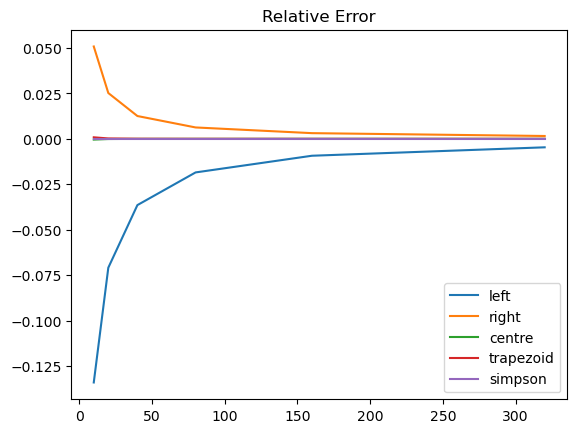

In [18]:
plt.plot([10, 20, 40, 80, 160, 320],(integral_l-np.exp(1)+1)/(np.exp(1)-1),label='left')
plt.plot([10, 20, 40, 80, 160, 320],(integral_r-np.exp(1)+1)/(np.exp(1)-1),label='right')
plt.plot([10, 20, 40, 80, 160, 320],(integral_c-np.exp(1)+1)/(np.exp(1)-1),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],(integral_t-np.exp(1)+1)/(np.exp(1)-1),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],(integral_s-np.exp(1)+1)/(np.exp(1)-1),label='simpson')
plt.legend()
plt.title('Relative Error')
plt.plot()

[]

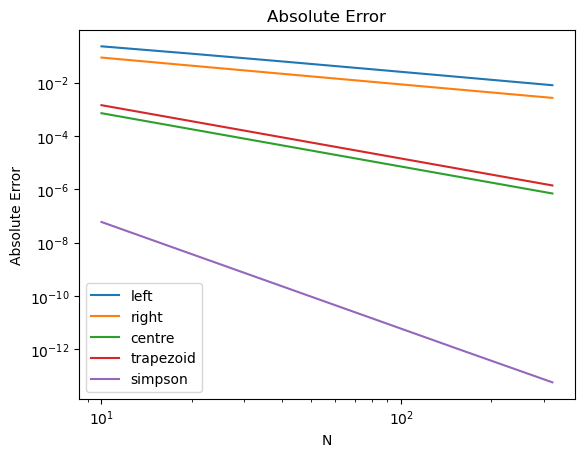

In [19]:
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_l-np.exp(1)+1),label='left')
#plt.scatter([10, 20, 40, 80, 160, 320],abs(integral_l-np.exp(1)+1),label='left')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_r-np.exp(1)+1),label='right')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_c-np.exp(1)+1),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_t-np.exp(1)+1),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_s-np.exp(1)+1),label='simpson')
plt.xlabel('N')
plt.ylabel('Absolute Error')
plt.xscale('log')
plt.yscale('log')
plt.title('Absolute Error')
plt.legend()
plt.plot()


In [20]:
import scipy

In [21]:
p_l = scipy.stats.linregress(np.log(N), np.log(abs(integral_l-np.exp(1)+1)))[0]
print(p_l) #atteso -1
p_r = scipy.stats.linregress(np.log(N), np.log(abs(integral_r-np.exp(1)+1)))[0]
print(p_r) #atteso -1
p_c = scipy.stats.linregress(np.log(N), np.log(abs(integral_c-np.exp(1)+1)))[0]
print(p_c) #atteso -2
p_t = scipy.stats.linregress(np.log(N), np.log(abs(integral_t-np.exp(1)+1)))[0]
print(p_t) #atteso -2
p_s = scipy.stats.linregress(np.log(N), np.log(abs(integral_s-np.exp(1)+1)))[0]
print(p_s) #atteso -4

-0.971032908446031
-1.0042818435959415
-1.9999305147336464
-1.9999602948433877
-3.9964153225902166


In [22]:
# for f4

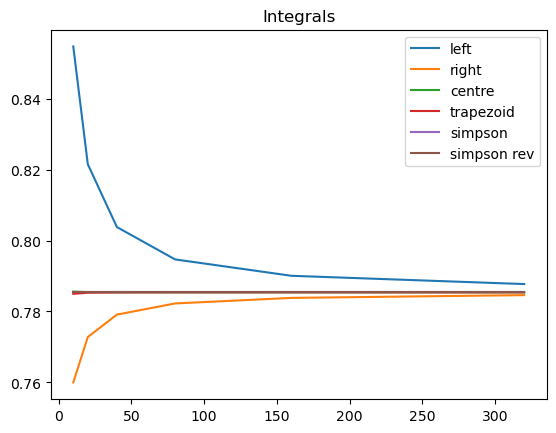

In [23]:
integral_l=[]
integral_r=[]
integral_c=[]
integral_t=[]
integral_s=[]
integral_sr=[]
N = [10, 20, 40, 80, 160, 320]
for i in [10, 20, 40, 80, 160, 320]:
    integral = left_rectangle((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_l.append(integral)
    
    integral = right_rectangle((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_r.append(integral)
    
    integral = central_rectangle((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_c.append(integral)

    integral = trap((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_t.append(integral)
    
    integral = simpson((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_s.append(integral)

    integral = simpson((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_sr.append(integral)

plt.plot([10, 20, 40, 80, 160, 320],integral_l,label='left')
plt.plot([10, 20, 40, 80, 160, 320],integral_r,label='right')
plt.plot([10, 20, 40, 80, 160, 320],integral_c,label='centre')
plt.plot([10, 20, 40, 80, 160, 320],integral_t,label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],integral_s,label='simpson')
plt.plot([10, 20, 40, 80, 160, 320],integral_sr,label='simpson rev')
plt.title('Integrals')
plt.legend()

In [24]:
integral_l = np.array(integral_l)
integral_r = np.array(integral_r)
integral_c = np.array(integral_c)
integral_t = np.array(integral_t)
integral_s = np.array(integral_s)
integral_sr = np.array(integral_sr)

[]

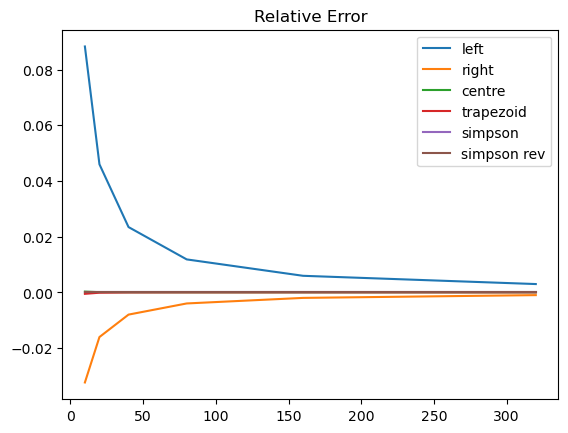

In [25]:
plt.plot([10, 20, 40, 80, 160, 320],(integral_l-np.pi/4)/(np.pi/4),label='left')
plt.plot([10, 20, 40, 80, 160, 320],(integral_r-np.pi/4)/(np.pi/4),label='right')
plt.plot([10, 20, 40, 80, 160, 320],(integral_c-np.pi/4)/(np.pi/4),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],(integral_t-np.pi/4)/(np.pi/4),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],(integral_s-np.pi/4)/(np.pi/4),label='simpson')
plt.plot([10, 20, 40, 80, 160, 320],(integral_sr-np.pi/4)/(np.pi/4),label='simpson rev')

plt.legend()
plt.title('Relative Error')
plt.plot()

[]

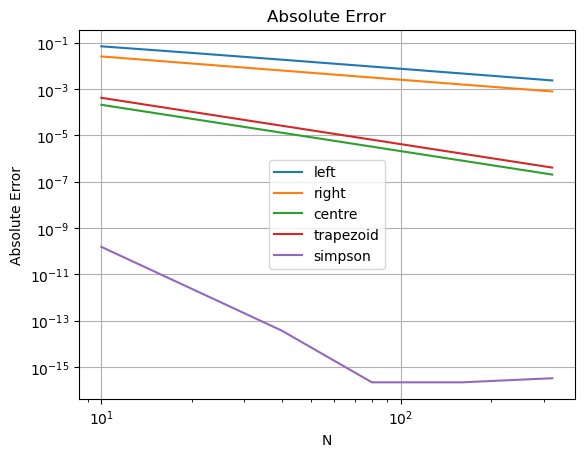

In [121]:
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_l-np.pi/4),label='left')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_r-np.pi/4),label='right')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_c-np.pi/4),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_t-np.pi/4),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_s-np.pi/4),label='simpson')
#plt.plot([10, 20, 40, 80, 160, 320],abs(integral_sr-np.pi/4),label='simpson rev')

plt.xlabel('N')
plt.ylabel('Absolute Error')
plt.xscale('log')
plt.yscale('log')
plt.title('Absolute Error')
plt.legend()
plt.grid()
plt.plot()


# perché simpson è molto più steep? termini extra
#derivate successive sono molto piccole: per effetto della derivata terza minuscola si scende al termine successivo che è h^6

In [27]:
p_l = scipy.stats.linregress(np.log(N), np.log(abs(integral_l-np.pi/4)))[0]
print(p_l) #atteso -1
p_r = scipy.stats.linregress(np.log(N), np.log(abs(integral_r-np.pi/4)))[0]
print(p_r) #atteso -1
p_c = scipy.stats.linregress(np.log(N), np.log(abs(integral_c-np.pi/4)))[0]
print(p_c) #atteso -2
p_t = scipy.stats.linregress(np.log(N), np.log(abs(integral_t-np.pi/4)))[0]
print(p_t) #atteso -2
p_s = scipy.stats.linregress(np.log(N[:-2]), np.log(abs(integral_s[:-2]-np.pi/4)))[0]
print(p_s) #atteso -4 --> viene molto più ripido!

-0.9798011531808148
-1.0042824465139533
-1.9999995070552874
-1.9999997451586797
-6.423848901513475


# 3

## Ex. 3.1

(a) For $h=10^0, 10^{-0.25}, 10^{-0.5}, \ldots, 10^{-16}$ (use np.logspace( $0,-16,65$ )), compute the absolute error of three approximations to $f^{\prime}\left(x_0\right)$ :
- Forward difference: $D_f=\left[f\left(x_0+h\right)-f\left(x_0\right)\right] / h$.
- Central difference: $D_c=\left[f\left(x_0+h\right)-f\left(x_0-h\right)\right] /(2 h)$.
- Complex step: $D_z=\operatorname{Im}\left[f\left(x_0+i h\right)\right] / h$.
  
(b) Plot all three error curves vs. $h$ on a single $\log -\log$ figure. Add dashed reference lines with the theoretical slopes ( $h^1, h^2$ for truncation; $h^{-1}$ for roundoff).

(c) From the plot, read off the approximate optimal $h_{\star}$ and minimum error $E_{\star}$ for forward and central differences. Fill in the table and compare with theory:
| Method | $h_{\star}$ (measured) | $h_{\star}$ (theory) | $E_{\star}$ (measured) | $E_{\star}$ (theory) |
| :--- | :--- | :--- | :--- | :--- |
| Forward | 1e-08 | $\sim \varepsilon^{1 / 2} \approx 1.5 \times 10^{-8}$ | 5.742479297632386e-09 | $\sim \varepsilon^{1 / 2} \approx 1.5 \times 10^{-8}$ |
| Central | 5.623413251903491e-06 | $\sim \varepsilon^{1 / 3} \approx 6 \times 10^{-6}$ | 9.969497449802134e-12 | $\sim \varepsilon^{2 / 3} \approx 4 \times 10^{-11}$ |
| Complex step |  | - (no floor) | machine precision! 1e-16 | $\sim \varepsilon$ |

(d) Why does the complex-step curve have no V-shape?
    There are no cancellations!

In [142]:
h = np.logspace(0, -16, 65)
print(h)

[1.00000000e+00 5.62341325e-01 3.16227766e-01 1.77827941e-01
 1.00000000e-01 5.62341325e-02 3.16227766e-02 1.77827941e-02
 1.00000000e-02 5.62341325e-03 3.16227766e-03 1.77827941e-03
 1.00000000e-03 5.62341325e-04 3.16227766e-04 1.77827941e-04
 1.00000000e-04 5.62341325e-05 3.16227766e-05 1.77827941e-05
 1.00000000e-05 5.62341325e-06 3.16227766e-06 1.77827941e-06
 1.00000000e-06 5.62341325e-07 3.16227766e-07 1.77827941e-07
 1.00000000e-07 5.62341325e-08 3.16227766e-08 1.77827941e-08
 1.00000000e-08 5.62341325e-09 3.16227766e-09 1.77827941e-09
 1.00000000e-09 5.62341325e-10 3.16227766e-10 1.77827941e-10
 1.00000000e-10 5.62341325e-11 3.16227766e-11 1.77827941e-11
 1.00000000e-11 5.62341325e-12 3.16227766e-12 1.77827941e-12
 1.00000000e-12 5.62341325e-13 3.16227766e-13 1.77827941e-13
 1.00000000e-13 5.62341325e-14 3.16227766e-14 1.77827941e-14
 1.00000000e-14 5.62341325e-15 3.16227766e-15 1.77827941e-15
 1.00000000e-15 5.62341325e-16 3.16227766e-16 1.77827941e-16
 1.00000000e-16]


In [172]:
def F1(x):
    return np.e**(np.sin(x))
def dF1(x):
    return np.exp(np.sin(x))*np.cos(x)
def F2(x):
    return (np.exp(x)-1)/x
def F3(x):
    return np.log(1+x**2)
def F4(x):
    return np.sqrt(x**2+10**(-20))

In [218]:
def Df(f,x0,h):
    return (f(x0+h)-f(x0))/h

def Dc(f,x0,h):
    return (f(x0+h)-f(x0-h))/(2*h)

def Di(f,x0,h):
    return (f(x0+h*1j)).imag/(h)

In [174]:
dF1(x01)

0.1918025795659312

Text(0.5, 1.0, 'Absolute Error')

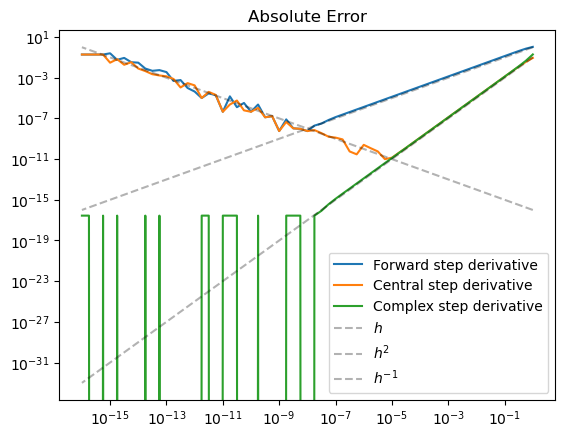

In [175]:
x01 = 1.5
Df_F1 = []
Dc_F1 = []
Di_F1 = []
for hi in h:
    Df_F1.append( Df(F1,x01,hi) )
    Dc_F1.append( Dc(F1,x01,hi) )
    Di_F1.append( Di(F1,x01,hi) )
err_Df_F1 = abs((Df_F1)-dF1(x01))
err_Dc_F1 = abs((Dc_F1)-dF1(x01))
err_Di_F1 = abs((Di_F1)-dF1(x01)) 

plt.plot(h,(err_Df_F1),label='Forward step derivative')
plt.plot(h,(err_Dc_F1),label='Central step derivative')
plt.plot(h,(err_Di_F1),label='Complex step derivative')
plt.plot(h,h,label=r'$h$',c='k',alpha=0.3,linestyle='--')
plt.plot(h,h**2*1e-1,label=r'$h^2$',c='k',alpha=0.3,linestyle='--')
plt.plot(h,h**(-1)*1e-16,label=r'$h^{-1}$',c='k',alpha=0.3,linestyle='--')
plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.title('Absolute Error')


In [176]:
hf = h[np.argmin(err_Df_F1)]
ef = err_Df_F1[np.argmin(err_Df_F1)]
print(hf,ef)
hc = h[np.argmin(err_Dc_F1)]
ec = err_Dc_F1[np.argmin(err_Dc_F1)]
print(hc,ec)
hi = h[np.argmin(err_Di_F1)]
ei = err_Di_F1[np.argmin(err_Di_F1)]
print(hi,ei)

1e-08 5.742479297632386e-09
5.623413251903491e-06 9.969497449802134e-12
1e-08 0.0


## Ex. 3.3

The function $f(x)=\left(e^x-1\right) / x$ suffers catastrophic cancellation near $x=0$ : at $x=10^{-8}$ the numerator computes $e^{10^{-8}}-1 \approx 10^{-8}$, losing about 8 significant digits.

(a) Evaluate $f\left(10^{-8}\right)$ in two ways:

Compare both with the exact value $f\left(10^{-8}\right)$. How many correct digits does the naive version give?

(b) Compute the forward-difference derivative of both versions (naive and stable) for $h=10^0, \ldots, 10^{-16}$. Plot both error curves. You should see:
- The naive version never achieves good accuracy (the V-curve floor is elevated).
- The stable version recovers the expected V-shape.
  
(c) Now compute the complex-step derivative of the naive version $\left(e^x-1\right) / x$ at $x_0=10^{-8}$ with $h=10^{-30}$. Does it recover full accuracy? Explain why or why not. (Hint: in the complex evaluation $e^{x+i h}$, the real and imaginary parts are computed independently; the cancellation in the real part does not contaminate the imaginary part.)

(d) Summarise: what combination of (function formulation) × (derivative method) gives reliable results here?

In [179]:
x0 = 1e-8
f_naive = ( np . exp ( x0 ) - 1) / x0
f_stable = np . expm1 ( x0 ) / x0

In [181]:
print(f_naive-1,f_stable-1)

-6.07747097092215e-09 5.00000019165725e-09


In [241]:
def F2_st(x0):
    return np.expm1 ( x0 ) / x0
def dF2(x):
    return (x*np.exp(x)-np.exp(x)+1)/x**2
def dF2_st(x):
    return (x*np.exp(x)-np.expm1(x))/x**2
def f2s(x):
    return (x*np.exp(x)-np.expm1(x))/x**2
print(dF2_st(1e-8))

0.4999999918875795


0.4999999918875795
[-4.03022947e-02 -1.30380382e-02 -4.15279114e-03 -1.31621615e-03
 -4.16516360e-04 -1.31736236e-04 -4.16538324e-05 -1.31645724e-05
 -4.15520706e-06 -1.30616856e-06 -4.05220777e-07 -1.20315803e-07
 -3.02209118e-08 -1.73040282e-09  7.27908717e-09  1.01281381e-08
  1.10290870e-08  1.13139917e-08  1.14040865e-08  1.14325767e-08
  1.14415672e-08  1.14443987e-08  1.14450874e-08  1.14455900e-08
  1.14470351e-08  1.14402419e-08  1.14202159e-08  1.13504194e-08
  1.11382736e-08  1.08851475e-08  1.05277533e-08  6.94161478e-09
  0.00000000e+00 -1.26802718e-09  5.33198286e-09 -4.61655991e-10
 -2.37507304e-08 -1.41406221e-08 -1.20092114e-09 -1.44946798e-08
 -1.50242334e-08  2.20093488e-09 -1.20627455e-08  7.16475779e-09
 -6.92279162e-09  6.43298481e-09 -7.51212392e-09  7.58129309e-09
 -1.27548179e-08 -5.82098508e-09  6.86394575e-09  5.21782284e-10
 -7.80481824e-09 -1.32336743e-08 -8.60647653e-09 -9.96830307e-09
  8.02189992e-09 -1.88292815e-08 -1.11773485e-09 -5.53064677e-09
 -1.16

/tmp/ipykernel_45072/3437680984.py:6: RuntimeWarning: invalid value encountered in divide
  return (np.exp(x)-1)/x
/tmp/ipykernel_45072/556425120.py:2: RuntimeWarning: invalid value encountered in divide
  return np.expm1 ( x0 ) / x0


Text(0.5, 1.0, 'Absolute Error')

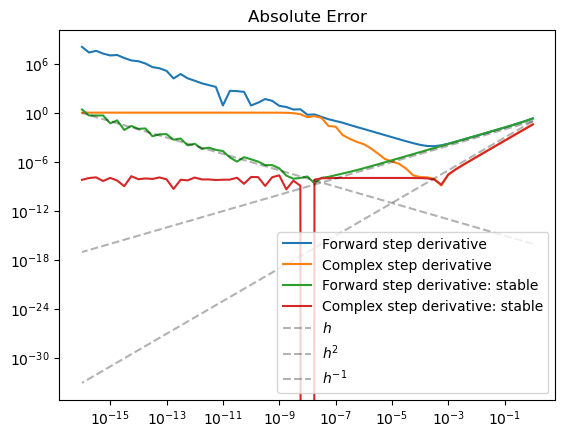

In [235]:
x01 = 1e-8
print(dF2_st(x01))
Df_F2 = ( Df(F2,x01,h) )
Dc_F2 = ( Dc(F2,x01,h) )
Di_F2 = ( Di(F2,x01,h))

Df_F2_st = ( Df(F2_st,x01,h) )
Dc_F2_st = ( Dc(F2_st,x01,h) )
Di_F2_st = ( Di(F2_st,x01,h) )
    
err_Df_F2 = abs((Df_F2)-dF2_st(x01))
err_Dc_F2 = abs((Dc_F2)-dF2_st(x01))
err_Di_F2 = abs((Di_F2)-dF2_st(x01)) 

err_Df_F2_st = abs((Df_F2_st)-dF2_st(x01))
err_Dc_F2_st = abs((Dc_F2_st)-dF2_st(x01))
err_Di_F2_st = abs((Di_F2_st)-dF2_st(x01)) 
print(Di_F2_st-dF2_st(x01))

plt.plot(h,(err_Df_F2),label='Forward step derivative')
plt.plot(h,(err_Di_F2),label='Complex step derivative')

plt.plot(h,(err_Df_F2_st),label='Forward step derivative: stable')
plt.plot(h,(err_Di_F2_st),label='Complex step derivative: stable')

plt.plot(h,h*1e-1,label=r'$h$',c='k',alpha=0.3,linestyle='--')
plt.plot(h,h**2*1e-1,label=r'$h^2$',c='k',alpha=0.3,linestyle='--')
plt.plot(h,h**(-1)*1e-16,label=r'$h^{-1}$',c='k',alpha=0.3,linestyle='--')
plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.title('Absolute Error')

In [ ]:
#Perchè non ce la fa ad andare sotto 1e-8? Problemi con expm1?

# 4

ex. 4.1

In [28]:
def f4(x):
    return x**3-2*x-5

In [29]:
xtrue = 2.0946
epsilon = 1e-3
xguess = 10